In [1]:
%load_ext autoreload

In [35]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0. Calculating activity scores
- Notebook where I calculated activity scores is at: [../../notebooks/Recalculating activity scores.ipynb](../../notebooks/Recalculating%20activity%20scores.ipynb)
    - Summary: 
        - Calculated activity per barcode
        - Removed barcodes with activity <100
        - Activity = barcode average. 
        - Error = barcode activity standard deviation
- Used controls to determine threshold of **1500** at [../../notebooks/Activity%20cutoff.ipynb](../../notebooks/Activity%20cutoff.ipynb)


# 1. Getting activity scores for one category at a time
To get the activity scores for your tile of interest:
1. Refer to visit2_seq_lib.csv
2. Look for a pattern in the "Description" column: Input is a [regular expression](https://regex101.com/) that would match your target descriptions. Can learn more about regular expressions [here](https://ds100.org/course-notes/regex/regex.html#regex-basics).



In [47]:
# Example 1: WT tiles
BasicArTh = sog1_helpers.return_activities("BasicArTh\.\d+") # Matches any descriptions containing BasicArTh, then a period, then some digits
BasicArTh.head(3)

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,1,40,BasicArTh.1,Q6NQK2,MAGRSWLIDSNRIATKIMSASASSDPRQVVWKSNPSRHCP,4745,578.263724,889.304271,12,-311.040547,1467.567995
1,11,50,BasicArTh.2,Q6NQK2,NRIATKIMSASASSDPRQVVWKSNPSRHCPKCQHVIDNSD,4968,465.385382,365.182128,7,100.203254,830.567509
2,21,60,BasicArTh.3,Q6NQK2,SASSDPRQVVWKSNPSRHCPKCQHVIDNSDVVDDWPGLPR,6208,680.357455,370.567756,11,309.789699,1050.925211


In [48]:
# Example 2:
PSv_conf2fD = sog1_helpers.return_activities("PSv_conf2fD$") # Matches any descriptions ending with "PSvconf2fD"
PSv_conf2fD

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end
0,61,100,7_PSv_conf2fD,/,GVKFDPSDPEIIWHLLAKSGLSGLSSHPFIDEFIPDVNQD,NaN,NaN,NaN,NaN,NaN,NaN
1,71,110,8_PSv_conf2fD,/,IIWHLLAKSGLSGLSSHPFIDEFIPDVNQDDGICYTHPKN,NaN,NaN,NaN,NaN,NaN,NaN
2,81,120,9_PSv_conf2fD,/,LSGLSSHPFIDEFIPDVNQDDGICYTHPKNLPGVKSDGTV,4663.0,1839.588076,1475.536928,3.0,364.051149,3315.125004
3,91,130,10_PSv_conf2fD,/,DEFIPDVNQDDGICYTHPKNLPGVKSDGTVSHFFHKAIKA,NaN,NaN,NaN,NaN,NaN,NaN
4,201,240,21_PSv_conf2fD,/,GDYVVSKIFYQQPQQLVVKRGDKAEQEVSEDIFAAVDPTA,NaN,NaN,NaN,NaN,NaN,NaN
5,211,250,22_PSv_conf2fD,/,QQPQQLVVKRGDKAEQEVSEDIFAAVDPTADPVDPKLADP,NaN,NaN,NaN,NaN,NaN,NaN
6,221,260,23_PSv_conf2fD,/,GDKAEQEVSEDIFAAVDPTADPVDPKLADPEPRNAVRICS,NaN,NaN,NaN,NaN,NaN,NaN
7,231,270,24_PSv_conf2fD,/,DIFAAVDPTADPVDPKLADPEPRNAVRICSDSHIASDYVT,NaN,NaN,NaN,NaN,NaN,NaN
8,241,280,25_PSv_conf2fD,/,DPVDPKLADPEPRNAVRICSDSHIASDYVTPSDYVSAHEV,NaN,NaN,NaN,NaN,NaN,NaN
9,311,350,32_PSv_conf2fD,/,LEHGLENGAKEMLDDKEEQEKDRDNENQGEEDPTWFDSGD,4545.0,624.176028,456.714710,12.0,167.461318,1080.890738


# 2. Plotting
I used pandas, seaborn, and matplotlib for my plotting. Here is an example:

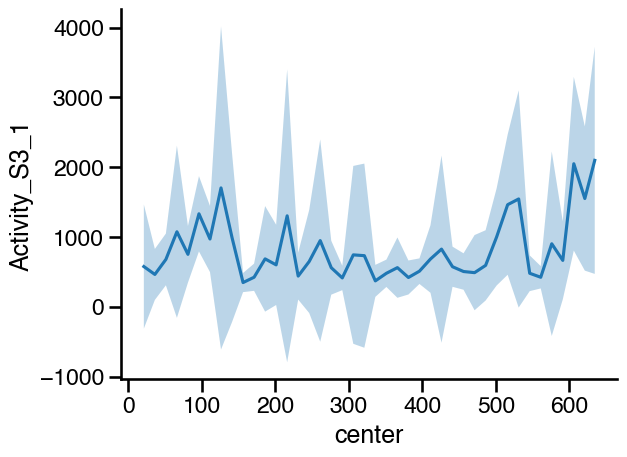

In [57]:
# Plotting WT trace.

# Adding tile center column
BasicArTh["center"]  = BasicArTh["Start"] + BasicArTh["End"] / 2

# Plotting the line plot of activity
sns.lineplot(data=BasicArTh, x="center", y="Activity_S3_1")

# Adding error shading
plt.fill_between(BasicArTh["center"], 
                 BasicArTh["Activity_S3_1"] - BasicArTh["Error"], 
                 BasicArTh["Activity_S3_1"] + BasicArTh["Error"], alpha=0.3)

sns.set_context("talk")
sns.despine()
